Generating CDFs
---

In [6]:
import numpy as np
import pandas as pd
from scipy.stats import uniform

import seaborn as sns 
import matplotlib.pyplot as plt

### Q1

In [4]:
#  Set up a grid of K equally spaced values between 0 and 1, {1/K, 2/K, ..., K/K}
K = 100
grid = np.arange(1, K+1)/K
grid

array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 , 0.11,
       0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21, 0.22,
       0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32, 0.33,
       0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43, 0.44,
       0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54, 0.55,
       0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65, 0.66,
       0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77,
       0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88,
       0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99,
       1.  ])

In [5]:
# Draw a point from the grid at random with equal probability.
point = np.random.choice(grid)
point

np.float64(0.62)

<Axes: ylabel='Proportion'>

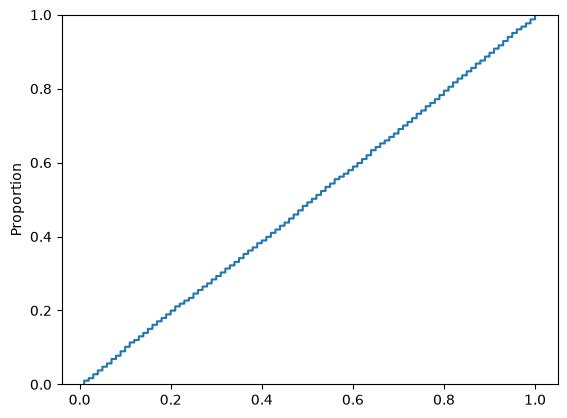

In [7]:
# For a very small , repeat the above process n = 5_000 times, and plot the ECDF of the draws
points = np.random.choice(grid, size=5000, replace=True)
sns.ecdfplot(data=points)

### What distribution does this approach as you increase K?
As you increase K, the distribution approached is a uniform distribution.

Q2
---

In [9]:
#  Draw n = 32 values from Uniform[-sqrt(3), sqrt(3)]; these are your data. The choice of +-3
#   ensures each draw has mean 0 and variance 1.
n= 32

sample = np.random.uniform(-np.sqrt(3), np.sqrt(3), n)
sample

array([-1.46427118,  0.4437363 ,  0.52993742, -0.47627965,  0.92631553,
       -1.34654353, -1.56153728, -0.15365261,  1.07823786, -1.55376648,
        0.88683026, -0.15854227,  1.03009293,  0.46661686, -1.15204943,
       -1.595091  , -1.61823762, -0.26959189, -1.47207688, -1.49425497,
       -0.12016019,  1.13915888,  0.58945728,  1.2302378 ,  0.41355243,
       -0.54122246, -1.39503197, -0.68890403, -0.39709133,  0.29121497,
       -1.26602453, -0.69003303])

In [12]:
# For this sample, compute the mean and multiply by np.sqrt(n)
mean_sqrt = np.mean(sample) * np.sqrt(n)
mean_sqrt

np.float64(-1.8365284614342678)

<Axes: ylabel='Proportion'>

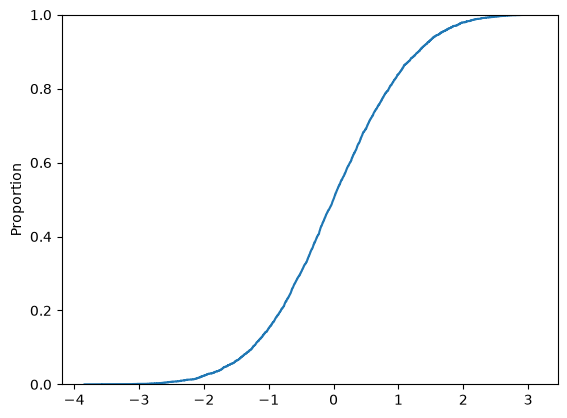

In [14]:
#  Repeat the above process b = 5_000 times and plot the ECDF
b = 5000
n=32
sample_means = []
for i in range(5000):
    sample = np.random.uniform(-np.sqrt(3), np.sqrt(3), n)
    mean_sqrt = np.mean(sample) * np.sqrt(n)
    sample_means.append(mean_sqrt)

sns.ecdfplot(data = sample_means)

 ### What distribution does this approach as n increases
normal distribution


Q3
---

In [15]:
# Flip n = 40 coins, which each come up heads with probability p=1/2 and tails with complementary
# probability.
n = 40
p= 0.5
heads = np.random.binomial(n, p)
heads

19

In [17]:
#  From the final count of heads, subtract the expected number of heads, n * p
heads_diff = heads - (n*p)
heads_diff

-1.0

In [18]:
#  Divide by the standard deviation sqrt( n * p * (1-p) )
headsdiff_over_std = heads_diff / np.sqrt(n*p*(1-p))
headsdiff_over_std

np.float64(-0.31622776601683794)

<Axes: ylabel='Proportion'>

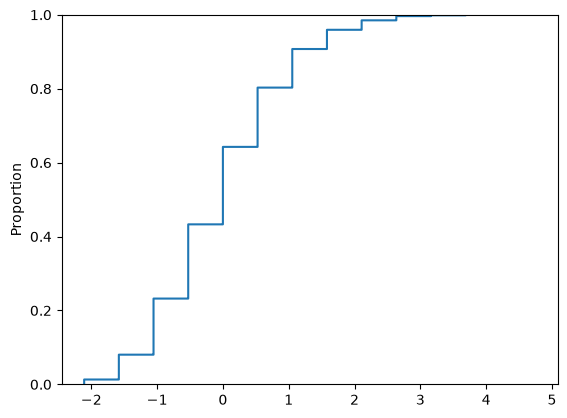

In [27]:
# Repeat the above process b = 5_000 times and plot the ECDF.
b = 5000
n = 40 #10000 #200 #40
p = 0.1#0.9# 0.5

vals = []
for i in range(5000):
    heads = np.random.binomial(n, p)
    heads_diff = heads - (n*p)
    headsdiff_over_std = heads_diff / np.sqrt(n*p*(1-p))
    vals.append(headsdiff_over_std)

sns.ecdfplot(data=vals)


### What distribution does this approach as n increases?
Normal distribution

### How do the results change as you adjust p ?
As the p values change, the plot becomes more skewed. If it is closer to 0, the line moves left, is closer to 1, the line moves right.

Q4
---

In [32]:
# For each simulation of the process, determine the period in which termination occurs
# dt is time interval of length 
# p of terminating = r*dt, r*dt < 1
dt = 0.001
r = 1

period = 0
terminate = False

while not terminate:
    period+=1
    num = np.random.random()
    print(num)
    if num < (r*dt):
        terminate = True
        print(num)
print(period)

0.8780761577077273
0.6242555513268232
0.4334658702977452
0.25373842227550114
0.058258134762859126
0.18518512232501116
0.9773394359855033
0.6501484687130457
0.36065820893901335
0.9414267386054254
0.6967539630440132
0.7517103376229572
0.9613173487110062
0.649565444960746
0.187636375014835
0.941351369064897
0.8332984596203361
0.8707664323790284
0.9569437980871051
0.01160959475765333
0.630842734608161
0.2226673778447965
0.22404178513067374
0.3089033366656093
0.35467199309183506
0.42620510217758145
0.8387024595762782
0.2630349129495896
0.6027874080007173
0.6969564363873062
0.6777612316111165
0.12081506766905015
0.6615061861114122
0.797157184920291
0.7644545813047351
0.2623104508504076
0.8459568018766402
0.5219216458503858
0.9303280656219178
0.5217130100220501
0.06048772350861564
0.5445567237443865
0.6626776237798933
0.6256447047881358
0.3024195842796963
0.25712013953911794
0.38609024180899887
0.059917667022719945
0.3988626571302112
0.9603205220131854
0.2799565461563309
0.18775925477223987
0

In [33]:
# Convert periods to time by multiplying by dt.
time  = period * dt
time

0.07100000000000001

In [43]:
# Repeat the simulation n = 5_000 times and plot the ECDF, for a value of dt close to zero (e.g. dt =1e-3)
dt = 0.001
r = 100 # 1
n = 5000
i = 0
times = []

while i < n:
    period = 0
    terminate = False
    while not terminate:
        period+=1
        if np.random.random() < (r*dt):
            terminate = True
    time = period * dt
    times.append(time)
    i+=1

<Axes: ylabel='Proportion'>

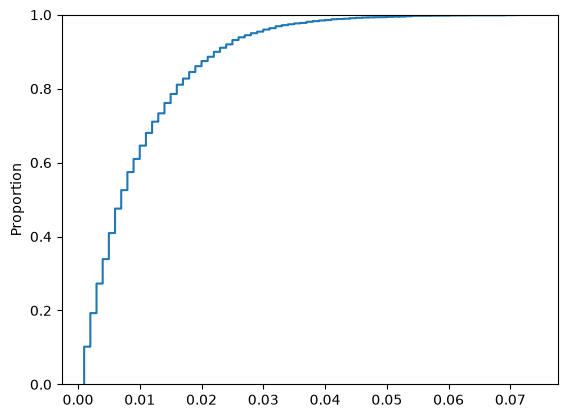

In [44]:
sns.ecdfplot(data=times)

### What distribution does this approach as dt  goes to zero?
Exponential Distribution

### How do the results change as you adjust r?
As r increases, the line gets steeper and starts to look like a vertical straight line

Q5
---

In [47]:
#  Draw K = 20  values from Uniform[0, 1]
k = 20
vals = np.random.uniform(0,1, k) 
vals




array([0.08590714, 0.37743459, 0.36352736, 0.67741394, 0.48139639,
       0.33332789, 0.85383749, 0.94030117, 0.16274685, 0.29310944,
       0.93709444, 0.07988188, 0.13075487, 0.31347008, 0.53503512,
       0.10781974, 0.65486984, 0.55158166, 0.59685952, 0.86646014])

In [50]:
# Sort them by size from smallest to largest
vals = np.sort(vals)
vals

array([0.07988188, 0.08590714, 0.10781974, 0.13075487, 0.16274685,
       0.29310944, 0.31347008, 0.33332789, 0.36352736, 0.37743459,
       0.48139639, 0.53503512, 0.55158166, 0.59685952, 0.65486984,
       0.67741394, 0.85383749, 0.86646014, 0.93709444, 0.94030117])

In [51]:
# Record the largest value
max = vals[-1]
max

np.float64(0.9403011697098014)

In [58]:
# Repeat n times and plot the ECDF
n = 5000
k= 20
max_vals = []
for i in range(n):
    vals = np.random.uniform(0, 1, k)
    vals = np.sort(vals)
    max = vals[-1]
    max_vals.append(max)

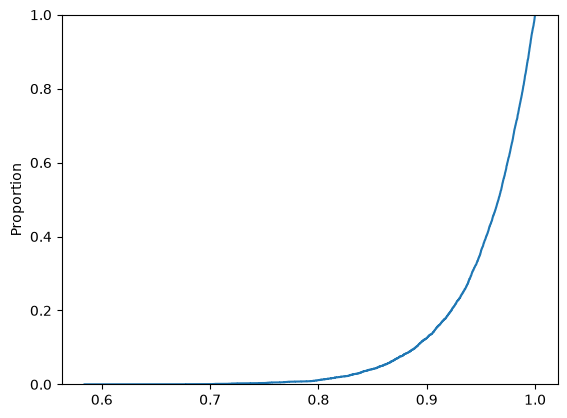

In [59]:
sns.ecdfplot(data=max_vals)
plt.show()

In [61]:
#  Repeat the previous steps for each rank from 1 to K.
n = 5000
k= 20
ranks = np.zeros((n, k))
for i in range(n):
    vals = np.random.uniform(0, 1, k)
    vals = np.sort(vals)
    ranks[i,:] = vals

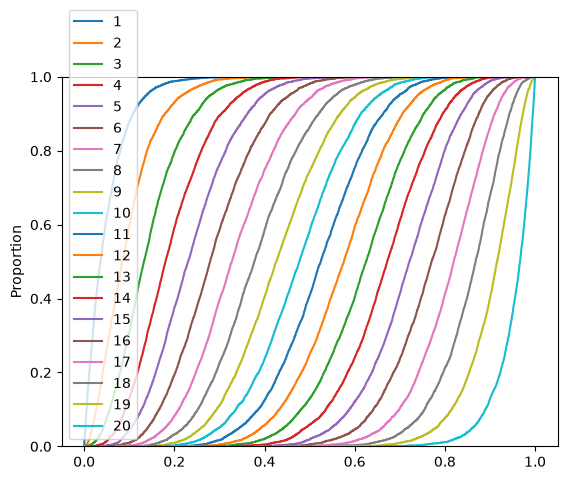

In [67]:
sns.ecdfplot(data=ranks[:, 0], label='1')
sns.ecdfplot(data=ranks[:, 1], label='2')
sns.ecdfplot(data=ranks[:, 2], label='3')
sns.ecdfplot(data=ranks[:, 3], label='4')
sns.ecdfplot(data=ranks[:, 4], label='5')
sns.ecdfplot(data=ranks[:, 5], label='6')
sns.ecdfplot(data=ranks[:, 6], label='7')
sns.ecdfplot(data=ranks[:, 7], label='8')
sns.ecdfplot(data=ranks[:, 8], label='9')
sns.ecdfplot(data=ranks[:, 9], label='10')
sns.ecdfplot(data=ranks[:, 10], label='11')
sns.ecdfplot(data=ranks[:, 11], label='12')
sns.ecdfplot(data=ranks[:, 12], label='13')
sns.ecdfplot(data=ranks[:, 13], label='14')
sns.ecdfplot(data=ranks[:, 14], label='15')
sns.ecdfplot(data=ranks[:, 15], label='16')
sns.ecdfplot(data=ranks[:, 16], label='17')
sns.ecdfplot(data=ranks[:, 17], label='18')
sns.ecdfplot(data=ranks[:, 18], label='19')
sns.ecdfplot(data=ranks[:, 19], label='20')


plt.legend()

### What distribution(s) does this process generate? How does the distribution depend on the rank?
Beta Distribution

The higher the rank, the more shifted to the right the line is


Q6
---

In [68]:
# Start at a state of 1.
state = 1

In [69]:
# Split a unit of time into 1/delta  small time steps. Start with delta = 1/100, so
# {0, 1/100, 2/100 ... 99/100}.
delta = 1/100

In [70]:
# part 3
u = np.exp(np.sqrt(delta))
d = np.exp(-np.sqrt(delta))

print(u)
print(d)

1.1051709180756477
0.9048374180359595


In [71]:
# Repeat steps 1-3 B = 1_000 times and record the final position, and plot the ECDF of your sample
b = 1000
states = []
for i in range(b):
    state = 1
    for i in range(100):
        if np.random.random() < 0.5:
            state = state * u
        else:
            state = state * d
    states.append(state)

<Axes: ylabel='Proportion'>

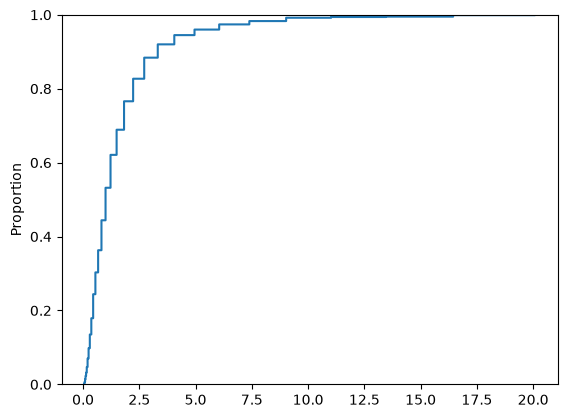

In [72]:
sns.ecdfplot(data=states)

### What distribution does this approach as delta  gets close to zero?
log normal distribution

Q7
---

In [77]:
#  Suppose there are K = 100_000 cities, ranked from largest to smallest. Create the ranks
k=100000
r = np.arange(1, k+1)
r

array([     1,      2,      3, ...,  99998,  99999, 100000],
      shape=(100000,))

In [85]:
# Zipf's law says that the size of the city with rank  is proportional to xr = (k/r)^s, s starts at 1
s = 10
sizes = (k/r)**s
sizes

array([1.00000000e+50, 9.76562500e+46, 1.69350878e+45, ...,
       1.00020002e+00, 1.00010001e+00, 1.00000000e+00], shape=(100000,))

In [86]:
#  Randomly sample n=5_000 ranks, with each rank equally likely, and record the corresponding sizes
n = 5000
samples = np.random.choice(r, size=n)
# samples

sample_sizes = (k/samples) **s

(0.0, 100.0)

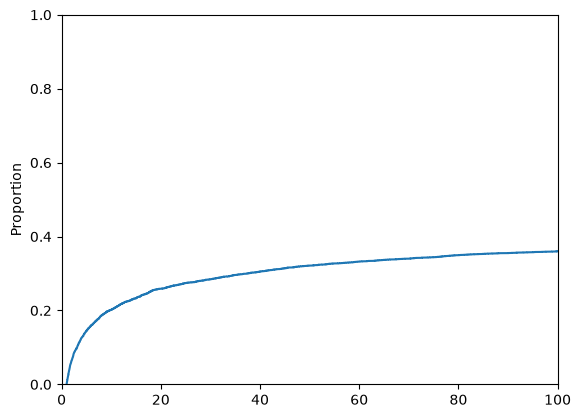

In [87]:
# Plot the ECDF of the simulated sizes
sns.ecdfplot(data=sample_sizes)
plt.xlim(0, 100)

### What distribution does this generate as k becomes large?
Pareto Distribution

### How does the distribution change as you adjust s?
The distribution becomes less steep when you increase s


Q8
---

In [98]:
# Initialize n = 1_000 particles with energy Ei = 1
n = 1000
energy = np.ones(n) * 6

In [99]:
#  Randomly choose two particles  and . Add their energies
i, j = np.random.choice(n, size=2, replace = False)
# print(i)
# print(j)

total = energy[i] + energy[j]
total

np.float64(12.0)

In [100]:
# Draw a uniformly distributed number from between 0 and 1,  and redistribute the energy
u = np.random.uniform(0, 1)
energy[i] = u* total
energy[j] = (1-u)*total


In [101]:
# Repeat this random exchange b=1_000_000 times
b = 1000000
for i in range(b):
    i, j = np.random.choice(n, size=2, replace=False)
    total=energy[i] + energy[j]
    u = np.random.uniform(0, 1)
    energy[i] = u*total
    energy[j] = (1-u)*total

<Axes: ylabel='Proportion'>

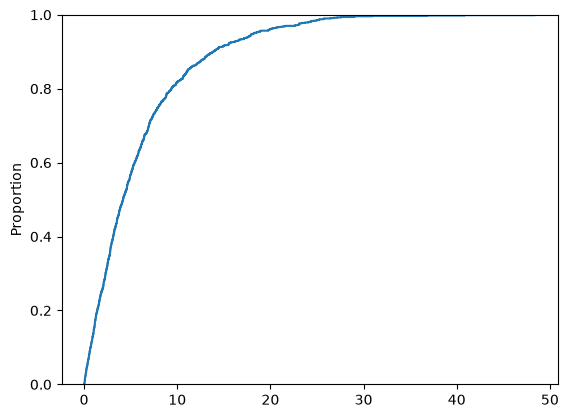

In [102]:
sns.ecdfplot(data=energy)

### What distribution does this simulation approach as n becomes large
exponential distribution

### How does the distribution change if you increase or decrease the initial energy for each particle
Increasing the initial energy spreads the distribution toward the larger energies. Decreasing the inital energy shifts the spread towards 0.
